In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime, timedelta

In [2]:
df = pd.read_csv('datasets/data.csv')

df.head(3)

,No,Water Meter ID,Reading ID,Reading Value,Reading Date,Previous Reading Value,Previous Reading Date,Reading Frequency,Reader ID,Type of Contract,Reading Validity,Certification on the ERP,Final Billing,Reason for Reading
0,1,IT-WM-001,READ-001,145.50,15/01/2024,120.30,15/12/2023,Monthly,READER-01,Residential,Valid,Yes,125.40,Routine
1,2,IT-WM-002,READ-002,89.75,16/01/2024,75.20,16/12/2023,Monthly,READER-02,Commercial,Valid,Yes,89.75,Routine
2,3,IT-WM-003,READ-003,NaN,17/01/2024,210.45,17/12/2023,Monthly,READER-03,Industrial,Invalid,No,0.00,Missing


Revisemos los tipos

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 501 entries, 0 to 500
Data columns (total 14 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   No                        501 non-null    int64  
 1   Water Meter ID            501 non-null    object 
 2   Reading ID                501 non-null    object 
 3   Reading Value             494 non-null    float64
 4   Reading Date              501 non-null    object 
 5   Previous Reading Value    494 non-null    float64
 6   Previous Reading Date     496 non-null    object 
 7   Reading Frequency         501 non-null    object 
 8   Reader ID                 499 non-null    object 
 9   Type of Contract          500 non-null    object 
 10  Reading Validity          501 non-null    object 
 11  Certification on the ERP  500 non-null    object 
 12  Final Billing             484 non-null    float64
 13  Reason for Reading        478 non-null    object 
dtypes: float64

In [4]:
# dates transform
times = ['Reading Date', 'Previous Reading Date']

for i in times:
    df[i] = pd.to_datetime(df[i], errors='coerce')
    df[i] = df[i].dt.strftime('%Y-%m-%d')
    print(df[i].head(3))
    print('\n')

0    2024-01-15
1    2024-01-16
2    2024-01-17
Name: Reading Date, dtype: object


0    2023-12-15
1    2023-12-16
2    2023-12-17
Name: Previous Reading Date, dtype: object




/tmp/ipykernel_5298/3314024531.py:5: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df[i] = pd.to_datetime(df[i], errors='coerce')
/tmp/ipykernel_5298/3314024531.py:5: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df[i] = pd.to_datetime(df[i], errors='coerce')


In [5]:
# bool transform
# iba a agregar final billing pero el dataset no cumple con las condiciones del diccionario
# asi que lo voy a dejar como esta
bools = ['Certification on the ERP']
for i in bools:
    df[i] = df[i].str.lower()
    df[i] = df[i].replace({'true': True, 'false': False, '0': False, '1': True})
    df[i] = df[i].astype(bool)
    print(df[i].head(3))
    print('\n')

# vality
# Replace values in 'Reading Validity' column using the replace() method
df['Reading Validity'] = df['Reading Validity'].replace(
    {'Valid': True, 'Invalid': False, 'Válido': True, 'Inválido': False, 'Valido': True, 'Sospetto': False}
)
df['Reading Validity'] = df['Reading Validity'].astype(bool)
print(df['Reading Validity'].head(3))

0    True
1    True
2    True
Name: Certification on the ERP, dtype: bool


0     True
1     True
2    False
Name: Reading Validity, dtype: bool


Lets delete the invalid data

In [6]:
invalid_data = (df['Reading Validity'] == False).sum()
df = df[df['Reading Validity'] == True]
print(invalid_data, '\n')

df['No'] = range(1, len(df)+1) 

35 



Calidad de los datos

Dimensiones

In [7]:
completitud = df.notnull().mean().round(3)
duplicados =  df.duplicated(subset=[col for col in df.columns if col != 'No']).sum()
porcentaje_duplicados = duplicados / len(df)
consistencia_fecha = (df['Previous Reading Date'] < df['Reading Date']).mean()
validez = (df['Reading Value'] >= 0).mean()
exactitud = 1
# falta exactitud

umbral = datetime(2024, 1, 1)
umbral = pd.to_datetime(umbral)
actualidad = (pd.to_datetime(df['Reading Date']) > umbral).mean()
integridad = df[['Reader ID', 'Reading ID']].notnull().all(axis=1).mean()

print(duplicados)


1


DASHBOARD

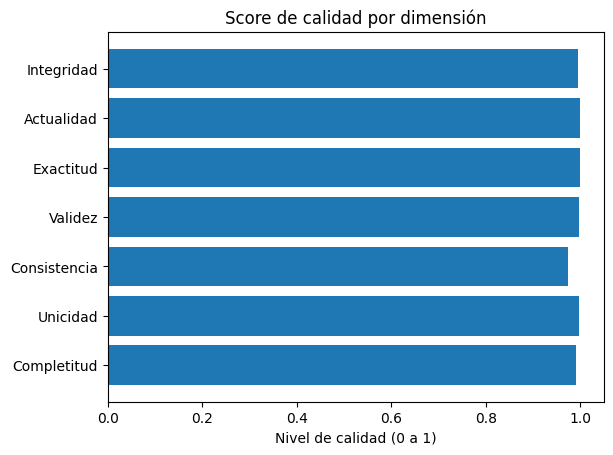

Bad pipe message: %s [b'"Microsoft Edge";v="141", "Not?A_Brand";v="8", "Chromium"']
Bad pipe message: %s [b'="141"\r\nsec-ch-ua-mobile: ?0\r\nsec-ch-ua-platform: "Windows']
Bad pipe message: %s [b'ol: max-age=0\r\nsec-ch-ua: "Microsoft Edge";v="141", "Not?A_Brand";v="8", "Chromium";v="141"\r\nsec-ch-ua-mobile: ?0\r\n']
Bad pipe message: %s [b'c-ch-ua-platform: "Windows"\r\nPrefer: safe\r\nUpgrade-Insecure-Requests: 1\r\nUser-Agent: Mozilla/5.0 (Windows NT 10.0;', b'in64; x64) AppleWebKit/537.36 (', b'TML, like Gecko) Chrome/141.0.0.0 Safari/537.36 Edg/141.0.0.0\r\nAccept: tex']
Bad pipe message: %s [b'html,application/xhtml+xml,application/xml;q=0.9,image/avif,image/webp,image/apng,*/*;q=0.8,application/signed-exch', b'ge;v=b3;q=0.7\r\nSec-Fetch-Site: none\r\nSec-Fetch-Mode: navigate\r\nSec-Fetch-User: ?1\r\nSec-Fetch-Des']
Bad pipe message: %s [b' document\r\nAccept-Encoding: gzip, deflate, br, zstd\r\nAccept-Language: es-CO,es-ES;q=0.9,es;q=0.8,en-US;q=0.7,en;q=0']


In [ ]:
dimensiones = ['Completitud', 'Unicidad', 'Consistencia', 'Validez', 'Exactitud', 'Actualidad', 'Integridad']

scores = [
    completitud.mean(),
    1 - porcentaje_duplicados,
    consistencia_fecha,
    validez,
    exactitud,
    actualidad,
    integridad
]
plt.barh(dimensiones, scores)
plt.xlabel('Nivel de calidad (0 a 1)')
plt.title('Score de calidad por dimensión')
plt.show()